# Phase 2 — Notebook 05 · Stage 2.2 diagnostics: why does L2/3 fail?

**Background.** In notebook 04 (Stage 2.2 a + b) we found:

* **Hash-aware Design B improves global metrics** over trace-only Design B.
* **Attention pooling improves global metrics most.**
* **L2/3 recall remains poor — particularly under attention.**

Improving global metrics while *worsening* L2/3 is a textbook "the model rebalanced itself toward easier classes" pattern. This notebook runs four targeted diagnostics to determine *what* causes the L2/3 collapse — confidence, error destinations, fold-level instability, or attention-driven mass migration. None of these diagnostics is a new architecture; they are reads on the existing models.

**Method.** We re-run hash-aware Design B for both pool variants on the same 5 GKF folds with the same seeds as notebook 04, but capture two extra things during inference:

1. The full per-test-neuron probability vector $p_i \in \mathbb{R}^4$ (used for diagnostics 1, 2, 3).
2. The full per-test-neuron attention weight vector $\alpha_i \in \mathbb{R}^{116}$ (only meaningful for `pool='attention'`; used for diagnostic 4).

Re-running is deterministic given the same seeds and partitions, so balanced-accuracy-level results match notebook 04 within MPS floating-point reproducibility.

**Diagnostics performed.**

1. **Probability margin per true class** — for every true layer $c$, the distribution of $\text{margin}_i = p_i(c) - \max_{c'\ne c} p_i(c')$ across test neurons. Small / negative margin = uncertain or wrong.
2. **False-negative destinations for L2/3** — for true L2/3 neurons predicted as L4 / L5 / L6, the average $p(\text{predicted})$ vs $p(L2/3)$ and the margin of the wrong call. Distinguishes "close call" misses from "confident wrong answer" misses.
3. **Per-fold L2/3 instability** — fold-by-fold counts (true L2/3 in test, predicted L2/3 in test, L2/3 in training, L2/3 recall, L2/3 precision). Identifies whether some folds are starved of L2/3 examples.
4. **Attention mass per true class** (attention pool only) — the entropy, max weight, and minimum number of hashes that carry 50% of attention mass, grouped by true class. Tests whether the attention head treats L2/3 differently (e.g. diffuse attention, or focusing on hashes that don't help layer decoding).

**Both pools (mean and attention) are run for diagnostics 1, 2, 3** so we can read whether L2/3 worsens *because of* attention (= attention specifically loses L2/3) vs L2/3 already poor under mean (= the whole hash-aware family has the same issue and attention only sharpens it).

Outputs: `data/processed/results/phase2_stage2_2_l23_diagnostics.parquet` (per-fold per-neuron predictions + diagnostic summaries).

## 0 · Environment

In [1]:
import os, sys, time, warnings
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import GroupKFold

from src.config import PROCESSED_RESULTS_DIR
from src.data.loaders import load_working_pop
from src.features.raw_traces import (
    remove_mismatch_neurons,
    build_single_session_e1,
    MAX_TRACE_LEN,
    load_oracle_hashes,
)
from src.models.cnn import LAYER_CLASSES
from src.models.cnn_deepsets import (
    HashAwareDeepSetsTraceCNN,
    build_e1_neuron_tensors_with_hashes,
    train_design_b_hash_fold,
    predict_neuron_proba_hash_with_attention,
    neuron_score_design_b,
)
from src.eval.cnn_eval import save_results, make_result_row

warnings.filterwarnings('ignore', category=UserWarning)

SEED        = 42
N_FOLDS     = 5
SESSION     = '5_6'
MAX_EPOCHS  = 80
PATIENCE    = 12
BATCH_SIZE  = 32
TRACE_EMBED = 64
HASH_EMBED  = 16
ROW_HIDDEN  = 64
HEAD_HIDDEN = 64
POOL_KINDS  = ['mean', 'attention']

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device       : {DEVICE}')
print(f'Pool kinds   : {POOL_KINDS}  → 2 × {N_FOLDS} = {2 * N_FOLDS} fits')
print(f'Seed strategy: per-fold seed = SEED + fold_k (matches notebook 04 exactly)')

Device       : mps
Pool kinds   : ['mean', 'attention']  → 2 × 5 = 10 fits
Seed strategy: per-fold seed = SEED + fold_k (matches notebook 04 exactly)


## 1 · Data, hash vocabulary, GKF folds, set tensors

Reproduces the notebook-04 setup exactly so the per-fold results re-derived here match those in notebook 04.

In [2]:
units_raw = load_working_pop()
units_clean, _ = remove_mismatch_neurons(units_raw, verbose=False)
df_session = build_single_session_e1(SESSION, units_clean, verbose=False)
n_neurons = df_session['nucleus_id'].nunique()

oracle_hashes, _ = load_oracle_hashes()
HASH_VOCAB = sorted(oracle_hashes)
N_HASHES   = len(HASH_VOCAB)

neurons_df = df_session[['nucleus_id', 'layer_label']].drop_duplicates().reset_index(drop=True)
neuron_ids = neurons_df['nucleus_id'].to_numpy()
gkf = GroupKFold(n_splits=N_FOLDS)
fold_of_neuron = np.full(len(neuron_ids), -1, dtype=np.int8)
for k, (_, te_idx) in enumerate(gkf.split(neuron_ids, groups=neuron_ids)):
    fold_of_neuron[te_idx] = k
neurons_df['gkf_fold'] = fold_of_neuron
df_session = df_session.merge(neurons_df[['nucleus_id', 'gkf_fold']], on='nucleus_id', how='left')

X, mask, y_str, nids, hash_ids, hash_vocab = build_e1_neuron_tensors_with_hashes(
    df_session, pad_to=MAX_TRACE_LEN, hash_vocab=HASH_VOCAB,
)
fold_lookup = neurons_df.set_index('nucleus_id')['gkf_fold'].to_dict()
fold_of = np.array([fold_lookup[int(n)] for n in nids], dtype=np.int8)

print(f'X        : {X.shape}  dtype={X.dtype}')
print(f'hash_ids : {hash_ids.shape}  range [{hash_ids.min()}, {hash_ids.max()}]')
print(f'fold_of  : counts {dict(zip(*np.unique(fold_of, return_counts=True)))}')
print(f'Hash vocab: {N_HASHES} oracle hashes')

X        : (685, 116, 113)  dtype=float32
hash_ids : (116,)  range [0, 115]
fold_of  : counts {0: 137, 1: 137, 2: 137, 3: 137, 4: 137}
Hash vocab: 116 oracle hashes


## 2 · Per-fold runner — train + capture per-neuron probabilities and attention

Identical training to notebook 04. Inference uses `predict_neuron_proba_hash_with_attention` which returns:

* `probs ∈ R^{N_test × 4}` — per-test-neuron softmax over the 4 layer classes;
* `weights ∈ R^{N_test × 116}` for `pool='attention'`, or `None` for `pool='mean'`.

We collect the per-fold tuples into a long-format DataFrame for downstream diagnostics.

In [3]:
PROB_COLS = ['p_L23', 'p_L4', 'p_L5', 'p_L6']

def run_pool_with_capture(pool: str):
    """Train 5 folds for `pool` and return:
        df_pred : DataFrame with one row per test neuron and columns
                  nucleus_id, fold, true_layer, pred_layer, p_L23..p_L6;
        attn_per_fold : dict fold_k -> (n_test, H) attention weights
                        (empty for pool='mean')."""
    rows_pred = []
    attn_per_fold = {}
    for k in range(N_FOLDS):
        ti = time.time()
        val_k = (k + 1) % N_FOLDS
        test_idx  = np.where(fold_of == k)[0]
        val_idx   = np.where(fold_of == val_k)[0]
        train_idx = np.where(~np.isin(fold_of, [k, val_k]))[0]

        X_tr, M_tr, y_tr = X[train_idx], mask[train_idx], y_str[train_idx]
        X_va, M_va, y_va = X[val_idx],   mask[val_idx],   y_str[val_idx]
        X_te, M_te, y_te = X[test_idx],  mask[test_idx],  y_str[test_idx]

        model, _ = train_design_b_hash_fold(
            X_tr, M_tr, y_tr,
            X_va, M_va, y_va,
            hash_ids=hash_ids,
            n_hashes=N_HASHES,
            in_channels=1, n_classes=4,
            trace_embed=TRACE_EMBED, hash_embed=HASH_EMBED,
            row_hidden=ROW_HIDDEN, head_hidden=HEAD_HIDDEN,
            dropout=0.25, kernel_size=5,
            pool=pool,
            batch_size=BATCH_SIZE,
            max_epochs=MAX_EPOCHS, patience=PATIENCE,
            lr=1e-3, weight_decay=1e-4,
            seed=SEED + k,
            device=DEVICE,
            verbose=False,
        )

        probs, weights = predict_neuron_proba_hash_with_attention(
            model, X_te, hash_ids, mask=M_te,
            batch_size=BATCH_SIZE, device=DEVICE,
        )
        y_pred = np.array(LAYER_CLASSES)[probs.argmax(axis=1)]

        for i, ti_idx in enumerate(test_idx):
            rows_pred.append({
                'nucleus_id': int(nids[ti_idx]),
                'fold':       k,
                'true_layer': y_te[i],
                'pred_layer': y_pred[i],
                **{col: float(probs[i, j]) for j, col in enumerate(PROB_COLS)},
            })
        if weights is not None:
            attn_per_fold[k] = (weights, np.array([int(nids[t]) for t in test_idx]),
                                y_te.copy(), y_pred.copy())
        bal = (y_pred == y_te).mean()
        print(f'  pool={pool:<10s} fold {k} | n_test={len(y_te):3d} | '
              f'acc={bal:.3f} | ({time.time()-ti:.1f}s)')

    df_pred = pd.DataFrame(rows_pred)
    df_pred['pool'] = pool
    return df_pred, attn_per_fold

print('Per-fold runner ready.')

Per-fold runner ready.


In [4]:
t0 = time.time()
preds = {}
attn  = {}
for pool in POOL_KINDS:
    print(f'\n──── pool={pool} ────')
    preds[pool], attn[pool] = run_pool_with_capture(pool)
df_all = pd.concat(preds.values(), ignore_index=True)
print(f'\nTotal training+inference time: {(time.time() - t0) / 60:.1f} min')
print(f'Captured per-neuron predictions: {len(df_all)} rows '
      f'({len(df_all)//len(POOL_KINDS)} per pool, '
      f'{len(df_all)//(len(POOL_KINDS)*N_FOLDS)} per fold).')


──── pool=mean ────
  pool=mean       fold 0 | n_test=137 | acc=0.489 | (29.0s)
  pool=mean       fold 1 | n_test=137 | acc=0.409 | (38.2s)
  pool=mean       fold 2 | n_test=137 | acc=0.474 | (34.7s)
  pool=mean       fold 3 | n_test=137 | acc=0.577 | (50.8s)
  pool=mean       fold 4 | n_test=137 | acc=0.489 | (45.2s)

──── pool=attention ────
  pool=attention  fold 0 | n_test=137 | acc=0.584 | (67.7s)
  pool=attention  fold 1 | n_test=137 | acc=0.504 | (54.1s)
  pool=attention  fold 2 | n_test=137 | acc=0.591 | (93.7s)
  pool=attention  fold 3 | n_test=137 | acc=0.547 | (28.0s)
  pool=attention  fold 4 | n_test=137 | acc=0.540 | (64.7s)

Total training+inference time: 8.4 min
Captured per-neuron predictions: 1370 rows (685 per pool, 137 per fold).


## 3 · Diagnostic 1 — Probability margin per true class

For each test neuron with true class $c$:

$$
\text{margin}_i = p_i(c) - \max_{c'\ne c} p_i(c')
$$

Margin is positive when the model assigns more probability to the true class than to any rival; the size of the margin is the model's *confidence* in the correct answer. Negative margin means the neuron is misclassified, with magnitude indicating how badly. We tabulate per-class mean / median / IQR / fraction with positive margin, separately for each pool.

**Interpretation.**

* L2/3 with low *or negative* mean margin → model is unsure / wrong on most L2/3 neurons.
* L2/3 with high mean $p(\max\,\text{other})$ but only slightly less $p(L2/3)$ → close-call misses; could be fixed by softer class weighting or a harder-to-game loss.
* L2/3 with very negative margin → model is *confidently wrong*; harder to fix at the loss level.

In [5]:
TRUE_TO_PROB_COL = {'L2/3':'p_L23', 'L4':'p_L4', 'L5':'p_L5', 'L6':'p_L6'}

def add_margin_columns(df_pool):
    df = df_pool.copy()
    p_true_arr = []
    p_max_other_arr = []
    for _, r in df.iterrows():
        col = TRUE_TO_PROB_COL[r['true_layer']]
        p_true = r[col]
        others = [r[c] for c in PROB_COLS if c != col]
        p_true_arr.append(p_true)
        p_max_other_arr.append(max(others))
    df['p_true'] = np.array(p_true_arr)
    df['p_max_other'] = np.array(p_max_other_arr)
    df['margin'] = df['p_true'] - df['p_max_other']
    return df

rows = []
df_with_margins = {}
for pool in POOL_KINDS:
    df_with_margins[pool] = add_margin_columns(preds[pool])
    for c in LAYER_CLASSES:
        sub = df_with_margins[pool][df_with_margins[pool]['true_layer'] == c]
        if len(sub) == 0: continue
        rows.append({
            'pool':           pool,
            'true_class':     c,
            'n_neurons':      len(sub),
            'mean_p_true':    f'{sub["p_true"].mean():.3f}',
            'mean_p_other':   f'{sub["p_max_other"].mean():.3f}',
            'mean_margin':    f'{sub["margin"].mean():+.3f}',
            'median_margin':  f'{sub["margin"].median():+.3f}',
            'frac_pos':       f'{(sub["margin"] > 0).mean():.3f}',
            'q25_margin':     f'{sub["margin"].quantile(0.25):+.3f}',
            'q75_margin':     f'{sub["margin"].quantile(0.75):+.3f}',
        })
d1_df = pd.DataFrame(rows)
print('Diagnostic 1 — probability margin per (pool × true class):\n')
print(d1_df.to_string(index=False))

Diagnostic 1 — probability margin per (pool × true class):

     pool true_class  n_neurons mean_p_true mean_p_other mean_margin median_margin frac_pos q25_margin q75_margin
     mean       L2/3        151       0.331        0.392      -0.062        -0.022    0.166     -0.082     -0.009
     mean         L4        249       0.342        0.387      -0.045        -0.010    0.438     -0.062     +0.018
     mean         L5        189       0.326        0.333      -0.007        +0.026    0.608     -0.085     +0.109
     mean         L6         96       0.750        0.117      +0.633        +0.795    0.885     +0.438     +0.908
attention       L2/3        151       0.325        0.430      -0.105        -0.068    0.060     -0.136     -0.026
attention         L4        249       0.358        0.390      -0.032        +0.018    0.647     -0.057     +0.052
attention         L5        189       0.393        0.313      +0.080        +0.075    0.635     -0.065     +0.245
attention         L6        

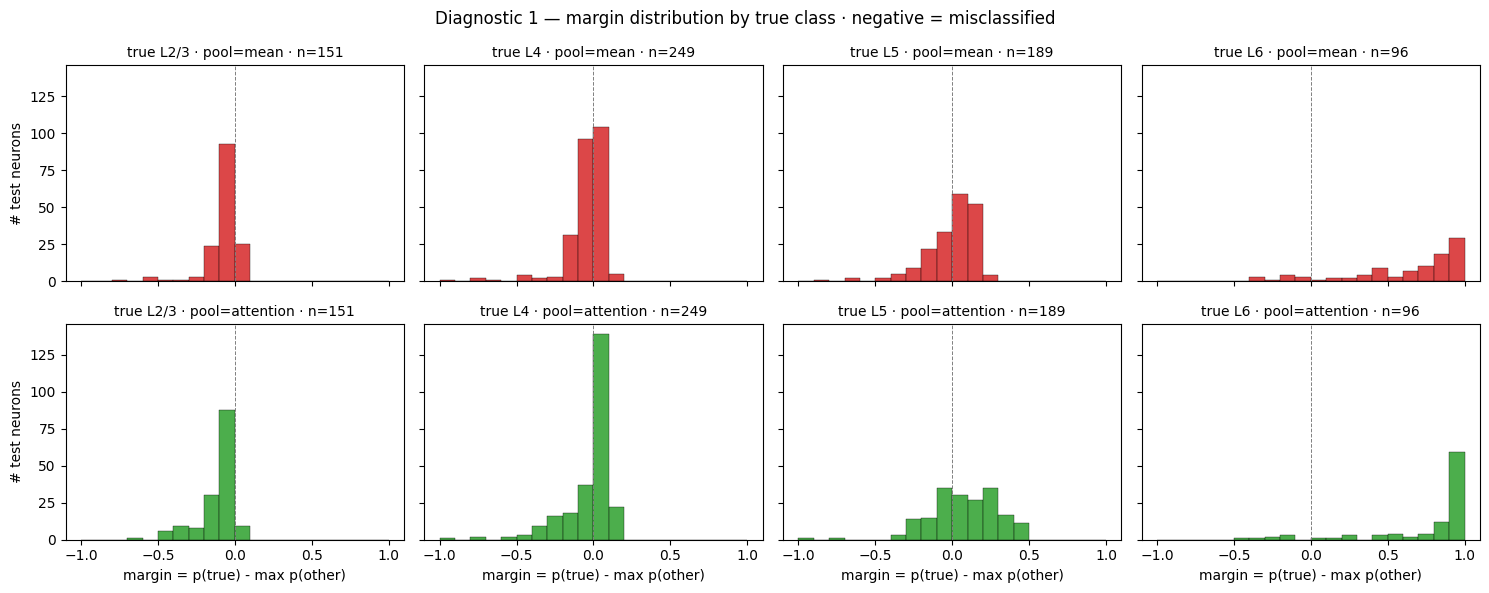

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharex=True, sharey=True)
for col, c in enumerate(LAYER_CLASSES):
    for row, pool in enumerate(POOL_KINDS):
        ax = axes[row, col]
        sub = df_with_margins[pool][df_with_margins[pool]['true_layer'] == c]
        ax.hist(sub['margin'], bins=np.linspace(-1, 1, 21), color=('C3' if pool=='mean' else 'C2'),
                alpha=0.85, edgecolor='k', linewidth=0.3)
        ax.axvline(0, color='gray', lw=0.7, ls='--')
        ax.set_title(f'true {c} · pool={pool} · n={len(sub)}', fontsize=10)
        if row == 1:
            ax.set_xlabel('margin = p(true) - max p(other)')
        if col == 0:
            ax.set_ylabel('# test neurons')
plt.suptitle('Diagnostic 1 — margin distribution by true class · negative = misclassified')
plt.tight_layout(); plt.show()

## 4 · Diagnostic 2 — False-negative destinations for L2/3

Filter to test neurons with `true_layer = L2/3` AND `pred_layer ≠ L2/3`. Group by `pred_layer ∈ {L4, L5, L6}` and tabulate:

* mean $p(\text{pred})$ — how confident the model was in the wrong answer;
* mean $p(L2/3)$ — how much L2/3 mass survived the wrong call;
* margin = $p(\text{pred}) - p(L2/3)$ — how decisive the misclassification was.

Small margin (e.g. 0.05) ⇒ close call; would respond to softer loss / temperature / re-balancing. Large margin (e.g. 0.30) ⇒ confident wrong answer; the model genuinely *believes* L2/3 is unlikely. We report this for both pools.

In [7]:
rows = []
for pool in POOL_KINDS:
    df = preds[pool]
    fn = df[(df['true_layer'] == 'L2/3') & (df['pred_layer'] != 'L2/3')].copy()
    n_total_l23 = (df['true_layer'] == 'L2/3').sum()
    rows.append({
        'pool': pool,
        'pred_destination': '— TOTAL L2/3 in test',
        'n':                int(n_total_l23),
        'avg_p_pred':       '—',
        'avg_p_L23':        f'{df[df["true_layer"]=="L2/3"]["p_L23"].mean():.3f}',
        'avg_margin_pred_minus_L23': '—',
    })
    for dest in ['L4','L5','L6']:
        sub = fn[fn['pred_layer'] == dest]
        if len(sub) == 0:
            rows.append({'pool': pool, 'pred_destination': dest, 'n': 0,
                         'avg_p_pred':'—','avg_p_L23':'—','avg_margin_pred_minus_L23':'—'})
            continue
        col_pred = TRUE_TO_PROB_COL[dest]
        rows.append({
            'pool':              pool,
            'pred_destination':  dest,
            'n':                 len(sub),
            'avg_p_pred':        f'{sub[col_pred].mean():.3f}',
            'avg_p_L23':         f'{sub["p_L23"].mean():.3f}',
            'avg_margin_pred_minus_L23': f'{(sub[col_pred] - sub["p_L23"]).mean():+.3f}',
        })
d2_df = pd.DataFrame(rows)
print('Diagnostic 2 — where do true-L2/3 errors go?\n')
print(d2_df.to_string(index=False))

Diagnostic 2 — where do true-L2/3 errors go?

     pool     pred_destination   n avg_p_pred avg_p_L23 avg_margin_pred_minus_L23
     mean — TOTAL L2/3 in test 151          —     0.331                         —
     mean                   L4  60      0.402     0.375                    +0.027
     mean                   L5  56      0.368     0.289                    +0.078
     mean                   L6  10      0.523     0.128                    +0.395
attention — TOTAL L2/3 in test 151          —     0.325                         —
attention                   L4  82      0.424     0.369                    +0.055
attention                   L5  58      0.445     0.265                    +0.180
attention                   L6   2      0.599     0.099                    +0.499


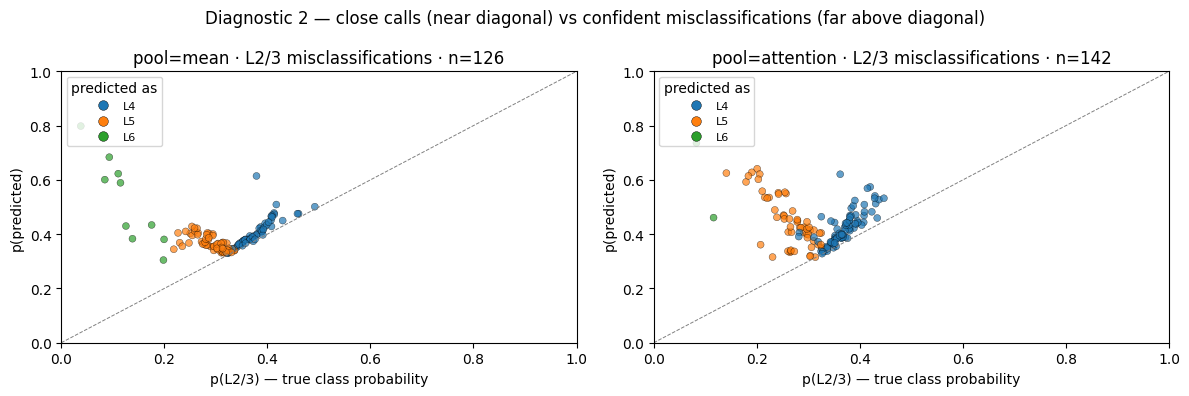

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pool in zip(axes, POOL_KINDS):
    df = preds[pool]
    fn = df[(df['true_layer'] == 'L2/3') & (df['pred_layer'] != 'L2/3')]
    if len(fn) == 0:
        ax.set_title(f'{pool}: no L2/3 errors'); continue
    p_pred = []; p_l23 = []; dest_color = []
    color_map = {'L4':'C0','L5':'C1','L6':'C2'}
    for _, r in fn.iterrows():
        p_pred.append(r[TRUE_TO_PROB_COL[r['pred_layer']]])
        p_l23.append(r['p_L23'])
        dest_color.append(color_map[r['pred_layer']])
    ax.scatter(p_l23, p_pred, c=dest_color, alpha=0.7, s=25, edgecolor='k', linewidth=0.3)
    ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=0.7)
    ax.set_xlabel('p(L2/3) — true class probability')
    ax.set_ylabel('p(predicted)')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f'pool={pool} · L2/3 misclassifications · n={len(fn)}')
    handles = [plt.Line2D([0],[0], marker='o', linestyle='', markersize=7, markerfacecolor=v,
                          markeredgecolor='k', markeredgewidth=0.3, label=k)
               for k, v in color_map.items()]
    ax.legend(handles=handles, fontsize=8, loc='upper left', title='predicted as')
plt.suptitle('Diagnostic 2 — close calls (near diagonal) vs confident misclassifications (far above diagonal)')
plt.tight_layout(); plt.show()

## 5 · Diagnostic 3 — Per-fold L2/3 instability

For each fold $k$:

* $n_{\text{train,L2/3}}$ — number of true L2/3 neurons in the training fold (excludes test fold $k$ AND val fold $(k+1)\bmod 5$);
* $n_{\text{test,L2/3}}$  — number of true L2/3 neurons in the test fold;
* $n_{\text{pred,L2/3}}$  — number of test neurons predicted L2/3;
* L2/3 recall    = TP / (TP + FN);
* L2/3 precision = TP / (TP + FP), `nan` when no L2/3 prediction is made.

Reported per pool. Folds with very few train L2/3 neurons or zero predicted L2/3 are flagged.

In [9]:
rows = []
for pool in POOL_KINDS:
    df = preds[pool]
    for k in range(N_FOLDS):
        val_k = (k + 1) % N_FOLDS
        train_neurons_idx = np.where(~np.isin(fold_of, [k, val_k]))[0]
        n_train_l23 = int((y_str[train_neurons_idx] == 'L2/3').sum())

        sub = df[df['fold'] == k]
        true_l23 = (sub['true_layer'] == 'L2/3')
        pred_l23 = (sub['pred_layer'] == 'L2/3')
        TP = int((true_l23 & pred_l23).sum())
        FN = int((true_l23 & ~pred_l23).sum())
        FP = int((~true_l23 & pred_l23).sum())
        n_test_l23 = int(true_l23.sum())
        n_pred_l23 = int(pred_l23.sum())
        recall    = TP / max(TP + FN, 1) if (TP + FN) > 0 else float('nan')
        precision = TP / (TP + FP) if (TP + FP) > 0 else float('nan')

        rows.append({
            'pool':         pool,
            'fold':         k,
            'n_train_L23':  n_train_l23,
            'n_test_L23':   n_test_l23,
            'n_pred_L23':   n_pred_l23,
            'TP':           TP,
            'FN':           FN,
            'FP':           FP,
            'L23_recall':   f'{recall:.3f}'    if not np.isnan(recall)    else 'nan',
            'L23_prec':     f'{precision:.3f}' if not np.isnan(precision) else 'nan',
        })
d3_df = pd.DataFrame(rows)
print('Diagnostic 3 — per-fold L2/3 instability:\n')
print(d3_df.to_string(index=False))

Diagnostic 3 — per-fold L2/3 instability:

     pool  fold  n_train_L23  n_test_L23  n_pred_L23  TP  FN  FP L23_recall L23_prec
     mean     0           90          32           0   0  32   0      0.000      nan
     mean     1           93          29          55  15  14  40      0.517    0.273
     mean     2           93          29           0   0  29   0      0.000      nan
     mean     3           90          29          11   4  25   7      0.138    0.364
     mean     4           87          32          23   6  26  17      0.188    0.261
attention     0           90          32           7   2  30   5      0.062    0.286
attention     1           93          29           5   0  29   5      0.000    0.000
attention     2           93          29           4   2  27   2      0.069    0.500
attention     3           90          29           9   4  25   5      0.138    0.444
attention     4           87          32           8   1  31   7      0.031    0.125


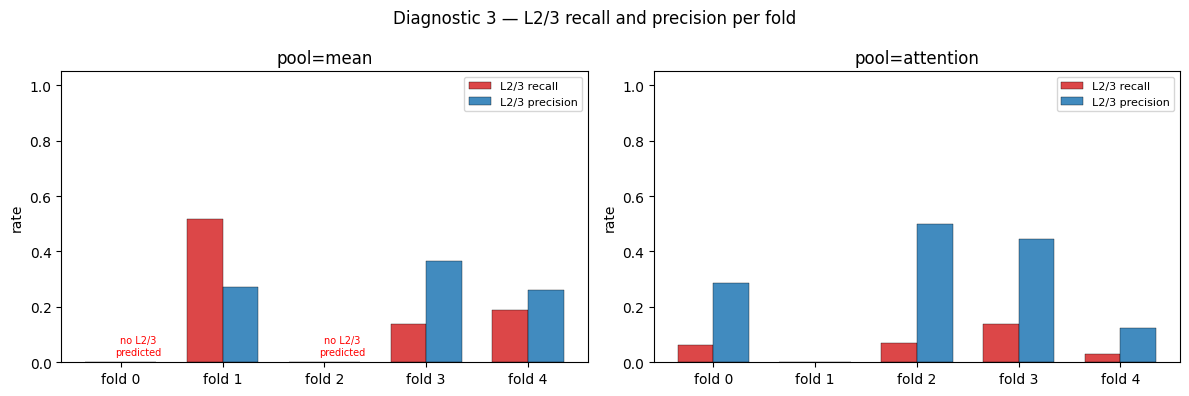

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pool in zip(axes, POOL_KINDS):
    sub = d3_df[d3_df['pool'] == pool].copy()
    sub['recall_num'] = pd.to_numeric(sub['L23_recall'], errors='coerce')
    sub['prec_num']   = pd.to_numeric(sub['L23_prec'],   errors='coerce')
    x = np.arange(N_FOLDS); w = 0.35
    ax.bar(x - w/2, sub['recall_num'].fillna(0), w, label='L2/3 recall',
           color='C3', alpha=0.85, edgecolor='k', linewidth=0.3)
    ax.bar(x + w/2, sub['prec_num'].fillna(0),   w, label='L2/3 precision',
           color='C0', alpha=0.85, edgecolor='k', linewidth=0.3)
    for i, (n_pred, recall) in enumerate(zip(sub['n_pred_L23'], sub['recall_num'])):
        if n_pred == 0:
            ax.text(i + w/2, 0.02, 'no L2/3\npredicted', ha='center', va='bottom',
                    fontsize=7, color='red')
    ax.set_xticks(x); ax.set_xticklabels([f'fold {k}' for k in range(N_FOLDS)])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('rate')
    ax.set_title(f'pool={pool}')
    ax.legend(fontsize=8)
plt.suptitle('Diagnostic 3 — L2/3 recall and precision per fold')
plt.tight_layout(); plt.show()

## 6 · Diagnostic 4 — Attention mass per true class (attention pool only)

For each test neuron under the **attention** pool we have a vector $\alpha_i \in \Delta^{H-1}$ with $\sum_h \alpha_{i,h} = 1$. We compute three summaries per neuron:

* **entropy** $H(\alpha_i) = -\sum_h \alpha_{i,h}\log\alpha_{i,h}$ — high entropy = diffuse attention; low entropy = concentrated.
* **max weight** $\max_h \alpha_{i,h}$ — peakedness of the most-attended hash.
* **top-50% mass** — minimum $k$ such that the $k$ largest $\alpha_{i,h}$ sum to ≥ 0.5.

We then aggregate by **true class**. The hypothesis is that *attention is causing L2/3 underprediction*; the prediction would be that attention is qualitatively different on true L2/3 neurons (e.g., more diffuse, or focused on hashes that don't carry L2/3-discriminating signal).

Note: chance entropy on 116 hashes is $\log 116 \approx 4.75$. A maximally concentrated attention has entropy 0.

In [11]:
if not attn['attention']:
    raise RuntimeError('No attention weights captured — was pool="attention" run?')

# Concatenate weights and labels across folds
all_w = np.vstack([attn['attention'][k][0] for k in sorted(attn['attention'])])
all_n = np.concatenate([attn['attention'][k][1] for k in sorted(attn['attention'])])
all_y_true = np.concatenate([attn['attention'][k][2] for k in sorted(attn['attention'])])
all_y_pred = np.concatenate([attn['attention'][k][3] for k in sorted(attn['attention'])])

# Sanity: each row sums to ~1
row_sums = all_w.sum(axis=1)
assert np.allclose(row_sums, 1.0, atol=1e-4), f'attention rows do not sum to 1; min/max={row_sums.min()}/{row_sums.max()}'

# Per-neuron summaries
eps = 1e-12
entropy   = -np.sum(all_w * np.log(all_w + eps), axis=1)         # (N_test_total,)
max_w     = all_w.max(axis=1)
sorted_w  = np.sort(all_w, axis=1)[:, ::-1]                       # descending
cum_w     = np.cumsum(sorted_w, axis=1)
top50_k   = (cum_w < 0.5).sum(axis=1) + 1                         # smallest k s.t. sum >= 0.5

log_uniform = np.log(N_HASHES)   # entropy of uniform distribution = log(116)

rows = []
for c in LAYER_CLASSES:
    sel = all_y_true == c
    if sel.sum() == 0: continue
    sel_correct = sel & (all_y_pred == c)
    sel_wrong   = sel & (all_y_pred != c)
    rows.append({
        'true_class':       c,
        'n_test':           int(sel.sum()),
        'mean_entropy':     f'{entropy[sel].mean():.3f}',
        'frac_of_uniform':  f'{entropy[sel].mean() / log_uniform:.3f}',
        'mean_max_w':       f'{max_w[sel].mean():.4f}',
        'mean_top50_k':     f'{top50_k[sel].mean():.1f}',
        'median_top50_k':   f'{int(np.median(top50_k[sel]))}',
        'entropy_correct':  f'{entropy[sel_correct].mean():.3f}' if sel_correct.sum() else 'nan',
        'entropy_wrong':    f'{entropy[sel_wrong].mean():.3f}'   if sel_wrong.sum()   else 'nan',
    })
rows.append({
    'true_class':       '— REFERENCE: uniform attention',
    'n_test':           N_HASHES,
    'mean_entropy':     f'{log_uniform:.3f}',
    'frac_of_uniform':  '1.000',
    'mean_max_w':       f'{1/N_HASHES:.4f}',
    'mean_top50_k':     f'{N_HASHES // 2}',
    'median_top50_k':   f'{N_HASHES // 2}',
    'entropy_correct':  '—',
    'entropy_wrong':    '—',
})
d4_df = pd.DataFrame(rows)
print('Diagnostic 4 — attention mass per true class (attention pool):\n')
print(d4_df.to_string(index=False))

Diagnostic 4 — attention mass per true class (attention pool):

                    true_class  n_test mean_entropy frac_of_uniform mean_max_w mean_top50_k median_top50_k entropy_correct entropy_wrong
                          L2/3     151        3.642           0.766     0.0748         12.2             11           3.716         3.637
                            L4     249        3.654           0.769     0.0706         12.6             12           3.740         3.497
                            L5     189        3.542           0.745     0.0901         10.0              9           3.450         3.702
                            L6      96        3.547           0.746     0.1098         10.6              7           3.548         3.538
— REFERENCE: uniform attention     116        4.754           1.000     0.0086           58             58               —             —


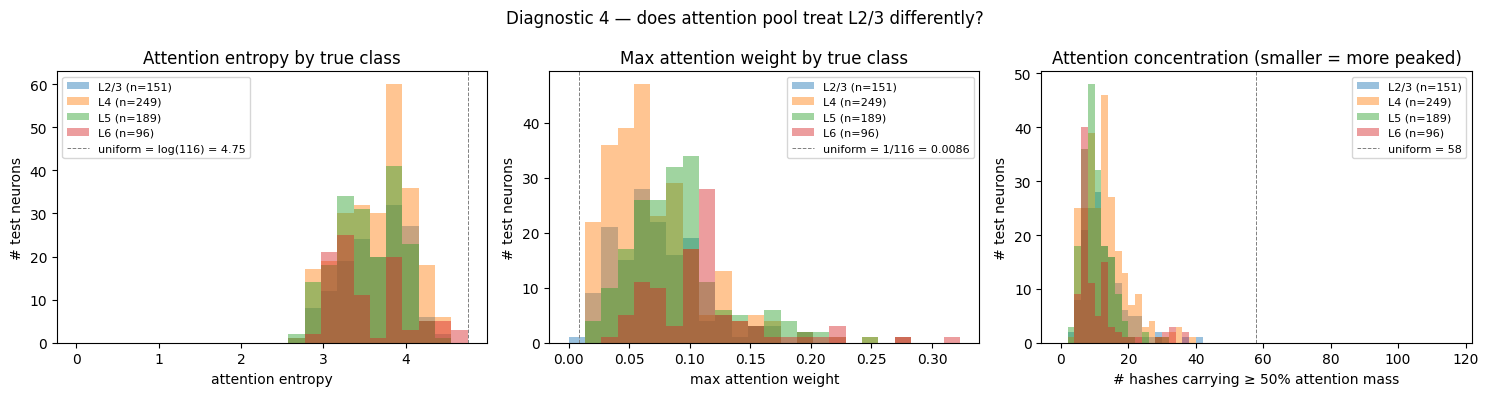

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Entropy distribution by true class
ax = axes[0]
for i, c in enumerate(LAYER_CLASSES):
    sel = all_y_true == c
    if sel.sum() == 0: continue
    ax.hist(entropy[sel], bins=np.linspace(0, log_uniform, 25), alpha=0.45,
            label=f'{c} (n={int(sel.sum())})')
ax.axvline(log_uniform, color='gray', ls='--', lw=0.7, label=f'uniform = log(116) = {log_uniform:.2f}')
ax.set_xlabel('attention entropy'); ax.set_ylabel('# test neurons')
ax.set_title('Attention entropy by true class')
ax.legend(fontsize=8)

# (b) Max weight by true class
ax = axes[1]
for c in LAYER_CLASSES:
    sel = all_y_true == c
    if sel.sum() == 0: continue
    ax.hist(max_w[sel], bins=np.linspace(0, max_w.max(), 25), alpha=0.45,
            label=f'{c} (n={int(sel.sum())})')
ax.axvline(1 / N_HASHES, color='gray', ls='--', lw=0.7, label=f'uniform = 1/116 = {1/N_HASHES:.4f}')
ax.set_xlabel('max attention weight'); ax.set_ylabel('# test neurons')
ax.set_title('Max attention weight by true class')
ax.legend(fontsize=8)

# (c) Top-50% mass concentration
ax = axes[2]
for c in LAYER_CLASSES:
    sel = all_y_true == c
    if sel.sum() == 0: continue
    ax.hist(top50_k[sel], bins=np.arange(0, N_HASHES + 2, 2), alpha=0.45,
            label=f'{c} (n={int(sel.sum())})')
ax.axvline(N_HASHES // 2, color='gray', ls='--', lw=0.7, label=f'uniform = 58')
ax.set_xlabel('# hashes carrying ≥ 50% attention mass')
ax.set_ylabel('# test neurons')
ax.set_title('Attention concentration (smaller = more peaked)')
ax.legend(fontsize=8)

plt.suptitle('Diagnostic 4 — does attention pool treat L2/3 differently?')
plt.tight_layout(); plt.show()

## 7 · Synthesis — what does it look like?

We collect the headline numbers from each diagnostic into one place and emit a planning-style reading.

In [13]:
verdicts = []

# D1: L2/3 confidence under each pool
for pool in POOL_KINDS:
    sub = df_with_margins[pool][df_with_margins[pool]['true_layer'] == 'L2/3']
    m = sub['margin']
    verdicts.append(
        f'D1 [{pool}] true L2/3: mean margin = {m.mean():+.3f} (median {m.median():+.3f}, '
        f'frac with margin > 0 = {(m > 0).mean():.2f})'
    )

# D2: where do L2/3 errors go (attention pool, mostly the question)
for pool in POOL_KINDS:
    df = preds[pool]
    fn = df[(df['true_layer'] == 'L2/3') & (df['pred_layer'] != 'L2/3')]
    if len(fn) == 0: continue
    counts = fn['pred_layer'].value_counts().to_dict()
    avg_margin_by_dest = {}
    for dest in ['L4','L5','L6']:
        sub = fn[fn['pred_layer'] == dest]
        if len(sub):
            avg_margin_by_dest[dest] = (sub[TRUE_TO_PROB_COL[dest]] - sub['p_L23']).mean()
    margins_str = ', '.join(f'→{d}={v:+.2f}' for d, v in avg_margin_by_dest.items())
    verdicts.append(
        f'D2 [{pool}] L2/3 errors: {dict(counts)} ; avg confident-margin in wrong direction: {margins_str}'
    )

# D3: training fold L2/3 starvation
for pool in POOL_KINDS:
    sub = d3_df[d3_df['pool'] == pool]
    train_l23 = sub['n_train_L23'].astype(int).to_numpy()
    pred_l23  = sub['n_pred_L23'].astype(int).to_numpy()
    starved = (pred_l23 == 0).sum()
    verdicts.append(
        f'D3 [{pool}] train_L23 across folds = {list(train_l23)} ; '
        f'predicted_L23 = {list(pred_l23)} ; folds with no L2/3 predicted = {starved}'
    )

# D4: attention shape per class
verdicts.append(
    f'D4 reference uniform entropy = {log_uniform:.3f} '
    f'(everything below this is concentrated)'
)
for c in LAYER_CLASSES:
    sel = all_y_true == c
    if sel.sum() == 0: continue
    verdicts.append(
        f'D4 attn[{c:>4}] mean entropy = {entropy[sel].mean():.3f} '
        f'({100 * entropy[sel].mean() / log_uniform:.0f}% of uniform), '
        f'mean max_w = {max_w[sel].mean():.3f}, '
        f'mean top-50% k = {top50_k[sel].mean():.1f} hashes'
    )

print('Stage 2.2 · L2/3 diagnostics · synthesis\n')
for v in verdicts:
    print('  • ' + v)

Stage 2.2 · L2/3 diagnostics · synthesis

  • D1 [mean] true L2/3: mean margin = -0.062 (median -0.022, frac with margin > 0 = 0.17)
  • D1 [attention] true L2/3: mean margin = -0.105 (median -0.068, frac with margin > 0 = 0.06)
  • D2 [mean] L2/3 errors: {'L4': 60, 'L5': 56, 'L6': 10} ; avg confident-margin in wrong direction: →L4=+0.03, →L5=+0.08, →L6=+0.39
  • D2 [attention] L2/3 errors: {'L4': 82, 'L5': 58, 'L6': 2} ; avg confident-margin in wrong direction: →L4=+0.05, →L5=+0.18, →L6=+0.50
  • D3 [mean] train_L23 across folds = [90, 93, 93, 90, 87] ; predicted_L23 = [0, 55, 0, 11, 23] ; folds with no L2/3 predicted = 2
  • D3 [attention] train_L23 across folds = [90, 93, 93, 90, 87] ; predicted_L23 = [7, 5, 4, 9, 8] ; folds with no L2/3 predicted = 0
  • D4 reference uniform entropy = 4.754 (everything below this is concentrated)
  • D4 attn[L2/3] mean entropy = 3.642 (77% of uniform), mean max_w = 0.075, mean top-50% k = 12.2 hashes
  • D4 attn[  L4] mean entropy = 3.654 (77% of u

## 8 · Persist diagnostic results

We save:

* the per-neuron prediction long table (both pools), so any future diagnostic can be re-derived without re-training;
* the per-class margin summary (Diagnostic 1);
* the per-fold L2/3 instability table (Diagnostic 3);
* the per-class attention summary (Diagnostic 4).

Diagnostic 2's full per-error rows are inside the per-neuron prediction table (filterable by `(true_layer == 'L2/3') AND (pred_layer != 'L2/3')`).

In [15]:
out_dir = Path('data/processed/results')
out_dir.mkdir(parents=True, exist_ok=True)

# Per-neuron predictions long table
df_all_with_margins = pd.concat(
    [add_margin_columns(preds[p]) for p in POOL_KINDS], ignore_index=True,
)
df_all_with_margins.to_parquet(out_dir / 'phase2_stage2_2_l23_diag_predictions.parquet')
print(f'Saved per-neuron predictions: {len(df_all_with_margins)} rows '
      f'→ phase2_stage2_2_l23_diag_predictions.parquet')

# Diagnostic tables (one parquet, three sheets via different model_name labels)
diag_rows = []

# D1
for _, r in d1_df.iterrows():
    diag_rows.append({
        'diagnostic':    'D1_margin_per_class',
        'pool':          r['pool'],
        'true_class':    r['true_class'],
        'fold':          'all',
        'n':             int(r['n_neurons']),
        'mean_p_true':   float(r['mean_p_true']),
        'mean_p_other':  float(r['mean_p_other']),
        'mean_margin':   float(r['mean_margin']),
        'median_margin': float(r['median_margin']),
        'frac_pos':      float(r['frac_pos']),
    })

# D3
for _, r in d3_df.iterrows():
    diag_rows.append({
        'diagnostic':    'D3_per_fold_L23',
        'pool':          r['pool'],
        'true_class':    'L2/3',
        'fold':          str(int(r['fold'])),
        'n_train_L23':   int(r['n_train_L23']),
        'n_test_L23':    int(r['n_test_L23']),
        'n_pred_L23':    int(r['n_pred_L23']),
        'TP':            int(r['TP']),
        'FN':            int(r['FN']),
        'FP':            int(r['FP']),
        'L23_recall':    float(r['L23_recall']) if r['L23_recall'] != 'nan' else np.nan,
        'L23_precision': float(r['L23_prec'])   if r['L23_prec']   != 'nan' else np.nan,
    })

# D4 (attention only)
for c in LAYER_CLASSES:
    sel = all_y_true == c
    if sel.sum() == 0: continue
    diag_rows.append({
        'diagnostic':    'D4_attention_mass',
        'pool':          'attention',
        'true_class':    c,
        'fold':          'all',
        'n_test':        int(sel.sum()),
        'mean_entropy':  float(entropy[sel].mean()),
        'log_uniform':   float(log_uniform),
        'frac_uniform':  float(entropy[sel].mean() / log_uniform),
        'mean_max_w':    float(max_w[sel].mean()),
        'mean_top50_k':  float(top50_k[sel].mean()),
    })

diag_df = pd.DataFrame(diag_rows)
diag_df.to_parquet(out_dir / 'phase2_stage2_2_l23_diag_summaries.parquet')
print(f'Saved diagnostic summaries: {len(diag_df)} rows '
      f'→ phase2_stage2_2_l23_diag_summaries.parquet')

Saved per-neuron predictions: 1370 rows → phase2_stage2_2_l23_diag_predictions.parquet
Saved diagnostic summaries: 22 rows → phase2_stage2_2_l23_diag_summaries.parquet


---

### How to read these diagnostics together

* **Close-call L2/3 problem (margin near 0, mostly predicted as L4):** softer class weights (`1/sqrt(n_c)` instead of `1/n_c`) or a temperature on the head will recover most of the lost L2/3 mass.
* **Confident-wrong L2/3 problem (margin ≪ 0, large $p(L4) - p(L2/3)$ on misses):** the model believes L2/3 is unlikely. This is a representation/feature problem; loss tweaks won't fix it. Consider richer features (Tier G amplitudes as a side input, or behavioral / reliability metadata).
* **Fold-starved L2/3 problem (some folds have very few train L2/3):** stratified GKF or repeated-CV with averaging. The fold partition is the limit, not the model.
* **Attention pool selectively diffuses on L2/3 (D4 mean entropy higher for L2/3 vs other classes):** attention is *part of* the cause. Sharper attention (lower temperature, sparsemax) or going back to mean pool restores L2/3.
* **Attention pool concentrates similarly across classes (D4 entropies match):** attention is not the L2/3 culprit; D1/D2/D3 will localise the cause to confidence, error structure, or fold imbalance.

These diagnostics do not produce a new claim about Phase 2; they are the evidence base for choosing the *next* architectural / loss / split intervention before scaling to Stage 2.3 on session 5_7.